In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

In [40]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [98]:
snapnum = 4

In [99]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [100]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

OSError: Unable to open file (unable to open file: name = '/cosma7/data/dp004/dc-zhan5/TNG300-1/output/groups_004/fof_subhalo_tab_004.0.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [101]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10


OSError: Unable to open file (unable to open file: name = '/cosma7/data/dp004/dc-zhan5/TNG300-1/output/groups_004/fof_subhalo_tab_004.0.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [63]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [68]:
cent_sfrs1 = subhalos["SubhaloSFR"][cent_mask_all]

In [ ]:
cent_flag1 = subhalos["SubhaloFlag"][cent_mask_all]

In [72]:
cent_sfrs = np.zeros(len(halos["GroupFirstSub"]))
cent_sfrs[(halos["GroupFirstSub"]>-1)] = cent_sfrs1
cent_sfrs[(halos["GroupFirstSub"]>-1)][cent_flag1 == 0] = 0
#cent_sfrs = np.log10(cent_sfrs)

In [77]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all & (subhalos["SubhaloFlag"] == 1)]

In [78]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all& (subhalos["SubhaloFlag"] == 1)]*1e10

In [79]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all& (subhalos["SubhaloFlag"] == 1)]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [80]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [81]:
sum_sfrs = np.zeros(len(halos["GroupFirstSub"]))
sum_sfrs[unique_ids] = sum_sfrs1
#sum_sfrs = np.log10(sum_sfrs)

In [82]:
mvir = np.log10(halos["Group_M_TopHat200"])+10

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [83]:
group_sfrs = halos["GroupSFR"]

In [84]:
cent_frac = cent_sfrs/group_sfrs

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [92]:
cent_frac = cent_sfrs/(cent_sfrs+sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: invalid value encountered in true_divide
  """Entry point for launching an IPython kernel.


In [93]:
dlogM = 0.1
mhalo_bins = np.arange(10,14.5, dlogM)

In [94]:
median_list = []
percentiles = [25, 50, 75]
nbins = len(mhalo_bins)
percentile_arr = np.zeros((len(percentiles),nbins), dtype=float)
bin_cents = np.zeros(nbins, dtype=float)
for i, m in enumerate(mhalo_bins):
    bin_mask = (mvir > m) & (mvir < m+dlogM)
    cfrac = cent_frac[bin_mask]
    median = np.nanmedian(cfrac)
    
    median_list.append(median)
    
    for ip, percentile in enumerate(percentiles):
        percentile_arr[ip][i] = np.nanpercentile(cfrac, q=percentile)
        
    bin_cents[i] = np.median(mvir[bin_mask])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1111: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/lib/nanfunctions.py:1366: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/fromnumeric.py:3373: RuntimeWarning: Mean of empty slice.
  out=out, **kwargs)
/cosma/local/Python/3.6.5/lib/python3.6/site-packages/numpy/core/_methods.py:170: RuntimeWarning: invalid value encountered in true_divide
  ret = ret.dtype.type(ret / rcount)


In [95]:
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)

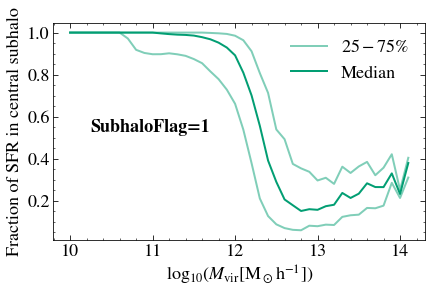

In [97]:
for i, p in enumerate(percentile_arr):
    if i == 1:
        alpha = 1
        label = "Median"
    else:
        alpha = 0.5
        label="25th-75th percentile"
    plt.plot(mhalo_bins, p, alpha=alpha, color=palette_tab10[2])

plt.legend(["$25-75 \%$", "Median"])

plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$$\rm[M_\odot h^{-1}$])")
plt.ylabel("Fraction of SFR in central subhalo")
ax = plt.gca()
ax.annotate("SubhaloFlag=1", (0.1,0.5), xycoords="axes fraction", ha="left", weight="bold")

#plt.savefig("../figures/halo_sfr_frac.pdf", format="pdf", bbox_inches="tight")